# MScFE 620 Derivative Pricing: Group Work Project 1
### Group submission: full solution (Q1–Q27)

**Student Group 15356:** 
| Names |
|---------|
| Peter Biyela |
| Bukunmi Enoch Akinyemi |
| Ijaz Hussain |

**Step 1 / Step 2 parameters:** $S_0=100$, $r=5\%$, $\sigma=20\%$, $T=0.25$ yr.

**Step 3 parameters:** $S_0=180$, $r=2\%$, $\sigma=25\%$, $T=0.5$ yr, $K=182$.

Vanilla options are priced with **binomial (CRR)** and **trinomial (Boyle)** trees; we compute the
Greeks **Delta** and **Vega**, verify **put-call parity**, graph price relationships, and run the
**dynamic delta-hedging** of Step 3. All prices are rounded to the nearest cent and shown in tables.

## Step 1: Put-Call Parity (Q1–Q4)

**Q1. Does put-call parity apply for European options?**

Yes. Put-call parity rests on the law of one price: two portfolios that produce the same payoff at
maturity must have the same value today. Because European options can only be exercised at
expiration, their payoffs can be replicated exactly using a combination of a European call, a
European put, the underlying stock, and a risk-free bond.

For a non-dividend-paying stock the relationship is

$$C + Ke^{-rT} = P + S_0,$$

where $C$ is the call price, $P$ the put price, $S_0$ the current stock price, and $Ke^{-rT}$ the
present value of the strike. It must hold in the binomial tree model, otherwise arbitrage
opportunities would exist.

**Q2. Solve put-call parity for the call price.**

Starting from $C + Ke^{-rT} = P + S_0$ and making $C$ the subject,

$$C = P + S_0 - Ke^{-rT}.$$

**Q3. Solve put-call parity for the put price.**

From the same identity, making $P$ the subject,

$$P = C + Ke^{-rT} - S_0.$$

**Q4. Does put-call parity apply for American options?**

No, strict put-call parity does not generally apply. American options can be exercised at any time
before expiration, while European options can only be exercised at maturity. This early-exercise
feature adds value, particularly for American puts, which makes exact replication more difficult.

The equality therefore becomes an inequality,

$$S_0 - K \le C_A - P_A \le S_0 - Ke^{-rT},$$

where $C_A$ and $P_A$ are the American call and put prices. American options satisfy these put-call
parity bounds rather than the exact equality, because the possibility of early exercise means the
European relationship does not generally hold.

## Pricing engines
CRR binomial and Boyle trinomial lattices; each prices European or American calls/puts by
backward induction with the early-exercise test $V=\max(\text{continuation},\text{intrinsic})$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

pd.set_option("display.float_format", lambda x: f"{x:0.2f}")
S0, r, sigma, T = 100.0, 0.05, 0.20, 0.25


def crr_tree(S, K, r, sigma, T, N, kind="call", american=False):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)
    j = np.arange(N + 1)
    ST = S * u**j * d ** (N - j)
    V = np.maximum(ST - K, 0) if kind == "call" else np.maximum(K - ST, 0)
    for i in range(N - 1, -1, -1):
        j = np.arange(i + 1)
        Si = S * u**j * d ** (i - j)
        V = disc * (p * V[1 : i + 2] + (1 - p) * V[0 : i + 1])
        if american:
            ex = np.maximum(Si - K, 0) if kind == "call" else np.maximum(K - Si, 0)
            V = np.maximum(V, ex)
    return float(V[0])


def crr_delta(S, K, r, sigma, T, N, kind="call", american=False):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)
    j = np.arange(N + 1)
    ST = S * u**j * d ** (N - j)
    V = np.maximum(ST - K, 0) if kind == "call" else np.maximum(K - ST, 0)
    Vu = Vd = None
    for i in range(N - 1, -1, -1):
        j = np.arange(i + 1)
        Si = S * u**j * d ** (i - j)
        V = disc * (p * V[1 : i + 2] + (1 - p) * V[0 : i + 1])
        if american:
            ex = np.maximum(Si - K, 0) if kind == "call" else np.maximum(K - Si, 0)
            V = np.maximum(V, ex)
        if i == 1:
            Vu, Vd = V[1], V[0]
    return float((Vu - Vd) / (S * u - S * d))


def trinomial_tree(S, K, r, sigma, T, N, kind="call", american=False):
    dt = T / N
    u = np.exp(sigma * np.sqrt(2 * dt))
    d = 1 / u
    a = np.exp(r * dt / 2)
    b1 = np.exp(sigma * np.sqrt(dt / 2))
    b2 = np.exp(-sigma * np.sqrt(dt / 2))
    pu = ((a - b2) / (b1 - b2)) ** 2
    pd = ((b1 - a) / (b1 - b2)) ** 2
    pm = 1 - pu - pd
    disc = np.exp(-r * dt)
    j = np.arange(2 * N + 1)
    ST = S * u ** (N - j)
    V = np.maximum(ST - K, 0) if kind == "call" else np.maximum(K - ST, 0)
    for i in range(N - 1, -1, -1):
        j = np.arange(2 * i + 1)
        Si = S * u ** (i - j)
        V = disc * (pu * V[0 : 2 * i + 1] + pm * V[1 : 2 * i + 2] + pd * V[2 : 2 * i + 3])
        if american:
            ex = np.maximum(Si - K, 0) if kind == "call" else np.maximum(K - Si, 0)
            V = np.maximum(V, ex)
    return float(V[0])


def bs(S, K, r, sigma, T, kind):
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if kind == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

### Step-count justification
Binomial prices oscillate around the true value and converge with $N$; stable to the cent by
$N\approx250$–$500$, so we use $N=500$ (binomial) and $N=200$ (trinomial).

In [2]:
rows = [
    {"N steps": N, "Binomial call": round(crr_tree(S0, 100, r, sigma, T, N, "call"), 4)}
    for N in [10, 25, 50, 100, 250, 500, 1000]
]
conv = pd.DataFrame(rows)
conv["Black-Scholes"] = round(bs(S0, 100, r, sigma, T, "call"), 4)
conv["abs error"] = (conv["Binomial call"] - conv["Black-Scholes"]).abs().round(4)
N_BIN, N_TRI = 500, 200
conv

,N steps,Binomial call,Black-Scholes,abs error
0,10,4.52,4.62,0.10
1,25,4.65,4.62,0.04
2,50,4.60,4.62,0.02
3,100,4.61,4.62,0.01
4,250,4.61,4.62,0.00
5,500,4.61,4.62,0.00
6,1000,4.61,4.62,0.00


## Q5: ATM European call & put (binomial tree)

In [3]:
K_atm = 100.0
q5 = pd.DataFrame(
    {
        "Option": ["European Call", "European Put"],
        "Price": [
            crr_tree(S0, K_atm, r, sigma, T, N_BIN, "call"),
            crr_tree(S0, K_atm, r, sigma, T, N_BIN, "put"),
        ],
    }
).round(2)
q5

,Option,Price
0,European Call,4.61
1,European Put,3.37


*(a) Number of steps.* We use 500 steps. The convergence table above settles to the nearest
cent well before that, so 500 gives a reliable price with room to spare.

*(b) Process and result.* The tree moves the stock up or down at each step and discounts the
expected payoff back to today. The at-the-money call is worth 4.61 and the put 3.37. The
call is the dearer of the two because the forward price sits above the strike, which is what
put-call parity leads us to expect.

## Q6: Delta of the European call & put (t = 0)

In [4]:
q6 = pd.DataFrame(
    {
        "Option": ["European Call", "European Put"],
        "Delta": [
            crr_delta(S0, K_atm, r, sigma, T, N_BIN, "call"),
            crr_delta(S0, K_atm, r, sigma, T, N_BIN, "put"),
        ],
    }
).round(4)
q6

,Option,Delta
0,European Call,0.57
1,European Put,-0.43


*(a) How they compare.* The call delta is about +0.57 and the put delta about −0.43. They sit
exactly one apart, which follows directly from put-call parity ($\Delta_C-\Delta_P=1$).

*(b) What delta means.* Delta is the hedge ratio: the number of shares that replicate the option,
and it roughly tracks the chance of finishing in the money. It is positive for the call, which gains
as the stock rises, and negative for the put, which gains as the stock falls.

## Q7: Vega of the European call & put (σ: 20% → 25%)

In [5]:
base = {
    "call": crr_tree(S0, K_atm, r, sigma, T, N_BIN, "call"),
    "put": crr_tree(S0, K_atm, r, sigma, T, N_BIN, "put"),
}
bump = {
    "call": crr_tree(S0, K_atm, r, 0.25, T, N_BIN, "call"),
    "put": crr_tree(S0, K_atm, r, 0.25, T, N_BIN, "put"),
}
q7 = pd.DataFrame(
    {
        "Option": ["European Call", "European Put"],
        "Price @ 20%": [base["call"], base["put"]],
        "Price @ 25%": [bump["call"], bump["put"]],
    }
).round(2)

q7["Change (+5% vol)"] = (q7["Price @ 25%"] - q7["Price @ 20%"]).round(2)
q7

,Option,Price @ 20%,Price @ 25%,Change (+5% vol)
0,European Call,4.61,5.60,0.99
1,European Put,3.37,4.35,0.98


*(a) Effect of higher volatility.* Raising volatility from 20% to 25% lifts the call from 4.61
to 5.60 (a gain of 0.99) and the put from 3.37 to 4.35 (a gain of 0.98). Both rise, so vega
is positive: more volatility widens the range of possible payoffs while the downside stays capped at
zero.

*(b) Call versus put.* The two move almost identically. For European options a call and a put on the
same strike share the same vega, because the forward leg that links them carries no volatility
risk.

## Q8: ATM American call & put (binomial tree)

In [6]:
q8 = pd.DataFrame(
    {
        "Option": ["Call", "Put"],
        "European": [
            crr_tree(S0, K_atm, r, sigma, T, N_BIN, "call", False),
            crr_tree(S0, K_atm, r, sigma, T, N_BIN, "put", False),
        ],
        "American": [
            crr_tree(S0, K_atm, r, sigma, T, N_BIN, "call", True),
            crr_tree(S0, K_atm, r, sigma, T, N_BIN, "put", True),
        ],
    }
).round(2)
q8["Early-exercise premium"] = (q8["American"] - q8["European"]).round(2)
q8

,Option,European,American,Early-exercise premium
0,Call,4.61,4.61,0.00
1,Put,3.37,3.48,0.11


*(a) Number of steps.* 500 steps, as in Q5.

*(b) Process and result.* The lattice is the same, but at every node we now take the larger of
holding on and exercising immediately. The American call comes out equal to the European call at
4.61. Without dividends there is never a reason to exercise a call early. The American put is
worth 3.48, which is 0.11 more than the European put (3.37). That extra value is the reward
for being able to exercise early.

## Q9: Delta of the American call & put (t = 0)

In [7]:
q9 = pd.DataFrame(
    {
        "Option": ["American Call", "American Put"],
        "Delta": [
            crr_delta(S0, K_atm, r, sigma, T, N_BIN, "call", True),
            crr_delta(S0, K_atm, r, sigma, T, N_BIN, "put", True),
        ],
    }
).round(4)
q9

,Option,Delta
0,American Call,0.57
1,American Put,-0.45


*(a) How they compare.* The call delta is about +0.57 and the put delta about −0.45, similar
in size and roughly one apart.

*(b) What delta means.* As before, delta is the hedge ratio and approximates the chance of finishing
in the money: positive for the call, negative for the put.

## Q10: Vega of the American call & put (σ: 20% → 25%)

In [8]:
base_a = {
    "call": crr_tree(S0, K_atm, r, sigma, T, N_BIN, "call", True),
    "put": crr_tree(S0, K_atm, r, sigma, T, N_BIN, "put", True),
}
bump_a = {
    "call": crr_tree(S0, K_atm, r, 0.25, T, N_BIN, "call", True),
    "put": crr_tree(S0, K_atm, r, 0.25, T, N_BIN, "put", True),
}
q10 = pd.DataFrame(
    {
        "Option": ["American Call", "American Put"],
        "Price @ 20%": [base_a["call"], base_a["put"]],
        "Price @ 25%": [bump_a["call"], bump_a["put"]],
    }
).round(2)
q10["Change (+5% vol)"] = (q10["Price @ 25%"] - q10["Price @ 20%"]).round(2)
q10

,Option,Price @ 20%,Price @ 25%,Change (+5% vol)
0,American Call,4.61,5.60,0.99
1,American Put,3.48,4.46,0.98


*(a) Effect of higher volatility.* The call rises from 4.61 to 5.60 (a gain of 0.99) and
the put from 3.48 to 4.46 (a gain of 0.98). Vega is positive for both.

*(b) Call versus put.* The impact at the money is almost the same for the two. The small difference
comes from the American put's early-exercise feature.

## Q11: European put-call parity check
Since Q1 = Yes, verify $C-P = S_0-Ke^{-rT}$ at the ATM strike.

In [9]:
C_eu = crr_tree(S0, K_atm, r, sigma, T, N_BIN, "call", False)
P_eu = crr_tree(S0, K_atm, r, sigma, T, N_BIN, "put", False)
lhs = C_eu - P_eu
rhs = S0 - K_atm * np.exp(-r * T)
q11 = pd.DataFrame(
    {"Quantity": ["C - P", "S0 - K e^{-rT}", "difference"], "Value": [lhs, rhs, lhs - rhs]}
).round(4)
q11

,Quantity,Value
0,C - P,1.24
1,S0 - K e^{-rT},1.24
2,difference,0.00


Parity holds: $C-P$ matches $S_0-Ke^{-rT}$ to the cent.

The reason is no-arbitrage. If the two sides differed, a trader could lock in a riskless profit, so
prices, and the tree that prices them, close the gap.

## Q12: American put-call parity check
Since Q4 = No, we expect the equality to fail; we show the band $S_0-K\le C-P\le S_0-Ke^{-rT}$.

In [10]:
C_am = crr_tree(S0, K_atm, r, sigma, T, N_BIN, "call", True)
P_am = crr_tree(S0, K_atm, r, sigma, T, N_BIN, "put", True)
q12 = pd.DataFrame(
    {
        "Quantity": ["C - P", "lower bound S0-K", "upper bound S0-K e^{-rT}", "gap vs upper"],
        "Value": [
            C_am - P_am,
            S0 - K_atm,
            S0 - K_atm * np.exp(-r * T),
            (S0 - K_atm * np.exp(-r * T)) - (C_am - P_am),
        ],
    }
).round(4)
q12

,Quantity,Value
0,C - P,1.13
1,lower bound S0-K,0.00
2,upper bound S0-K e^{-rT},1.24
3,gap vs upper,0.11


The equality does not hold here: $C-P$ lands strictly inside the band rather than on its upper
edge.

The shortfall against the upper bound, about 0.11, is the American put's early-exercise
premium, which is exactly what breaks the clean European equality.

## Q13: European call ≤ American call

In [11]:
q13 = pd.DataFrame(
    {
        "Strike": [K_atm],
        "European Call": [crr_tree(S0, K_atm, r, sigma, T, N_BIN, "call", False)],
        "American Call": [crr_tree(S0, K_atm, r, sigma, T, N_BIN, "call", True)],
    }
)
q13["Difference"] = q13["American Call"] - q13["European Call"]
q13.round(4)

,Strike,European Call,American Call,Difference
0,100.00,4.61,4.61,0.00


The difference is zero: with no dividends an American call is never exercised early, so it is
worth exactly the same as the European call.

This is not a universal rule, though. When the stock pays dividends, exercising just before a
dividend can make the American call strictly more valuable.

## Q14: European put ≤ American put

In [12]:
q14 = pd.DataFrame(
    {
        "Strike": [K_atm],
        "European Put": [crr_tree(S0, K_atm, r, sigma, T, N_BIN, "put", False)],
        "American Put": [crr_tree(S0, K_atm, r, sigma, T, N_BIN, "put", True)],
    }
)
q14["Difference"] = q14["American Put"] - q14["European Put"]
q14.round(4)

,Strike,European Put,American Put,Difference
0,100.00,3.37,3.48,0.11


The difference is about 0.11, and it is positive.

An American put is always worth at least as much as its European twin, because the freedom to
exercise early can only add value. It is strictly more valuable whenever early exercise is sometimes
worthwhile, as it is here. So $P_{Eu}\le P_{Am}$ always holds.

## Q15 & Q16: Trinomial European calls and puts across 5 strikes
Moneyness $K/S_0\in\{90,95,100,105,110\}\%$. For calls this runs Deep ITM → Deep OTM; for puts it
runs Deep OTM → Deep ITM.

In [13]:
moneyness = [0.90, 0.95, 1.00, 1.05, 1.10]
strikes = [m * S0 for m in moneyness]
q15 = pd.DataFrame(
    {
        "Moneyness K/S0": [f"{int(m*100)}%" for m in moneyness],
        "Strike K": strikes,
        "Call status": ["Deep ITM", "ITM", "ATM", "OTM", "Deep OTM"],
        "European Call": [
            trinomial_tree(S0, K, r, sigma, T, N_TRI, "call", False) for K in strikes
        ],
    }
).round(2)
q15

,Moneyness K/S0,Strike K,Call status,European Call
0,90%,90.00,Deep ITM,11.67
1,95%,95.00,ITM,7.71
2,100%,100.00,ATM,4.61
3,105%,105.00,OTM,2.48
4,110%,110.00,Deep OTM,1.19


**Q15.** Call prices fall as the strike rises. A higher strike means a smaller payoff
$\max(S_T-K,0)$, so the option costs less. This is the trend we would expect.

In [14]:
q16 = pd.DataFrame(
    {
        "Moneyness K/S0": [f"{int(m*100)}%" for m in moneyness],
        "Strike K": strikes,
        "Put status": ["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM"],
        "European Put": [trinomial_tree(S0, K, r, sigma, T, N_TRI, "put", False) for K in strikes],
    }
).round(2)
q16

,Moneyness K/S0,Strike K,Put status,European Put
0,90%,90.00,Deep OTM,0.55
1,95%,95.00,OTM,1.53
2,100%,100.00,ATM,3.37
3,105%,105.00,ITM,6.17
4,110%,110.00,Deep ITM,9.83


**Q16.** Put prices rise with the strike, since a higher strike enlarges the payoff
$\max(K-S_T,0)$. Calls and puts therefore move in opposite directions in the strike, just as parity
requires.

## Q17 & Q18: Trinomial American calls and puts across 5 strikes

In [15]:
q17 = pd.DataFrame(
    {
        "Moneyness K/S0": [f"{int(m*100)}%" for m in moneyness],
        "Strike K": strikes,
        "Call status": ["Deep ITM", "ITM", "ATM", "OTM", "Deep OTM"],
        "American Call": [trinomial_tree(S0, K, r, sigma, T, N_TRI, "call", True) for K in strikes],
        "European Call": [
            trinomial_tree(S0, K, r, sigma, T, N_TRI, "call", False) for K in strikes
        ],
    }
).round(2)
q17

,Moneyness K/S0,Strike K,Call status,American Call,European Call
0,90%,90.00,Deep ITM,11.67,11.67
1,95%,95.00,ITM,7.71,7.71
2,100%,100.00,ATM,4.61,4.61
3,105%,105.00,OTM,2.48,2.48
4,110%,110.00,Deep OTM,1.19,1.19


**Q17.** American call prices fall as the strike rises, and they match the European call at every
strike. With no dividends there is no early exercise, so the two are identical.

In [16]:
q18 = pd.DataFrame(
    {
        "Moneyness K/S0": [f"{int(m*100)}%" for m in moneyness],
        "Strike K": strikes,
        "Put status": ["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM"],
        "American Put": [trinomial_tree(S0, K, r, sigma, T, N_TRI, "put", True) for K in strikes],
        "European Put": [trinomial_tree(S0, K, r, sigma, T, N_TRI, "put", False) for K in strikes],
    }
).round(2)
q18["Early-exercise premium"] = (q18["American Put"] - q18["European Put"]).round(2)
q18

,Moneyness K/S0,Strike K,Put status,American Put,European Put,Early-exercise premium
0,90%,90.00,Deep OTM,0.56,0.55,0.01
1,95%,95.00,OTM,1.57,1.53,0.04
2,100%,100.00,ATM,3.48,3.37,0.11
3,105%,105.00,ITM,6.42,6.17,0.25
4,110%,110.00,Deep ITM,10.33,9.83,0.50


**Q18.** American put prices rise with the strike and sit above the European put at every
strike. The gap is the early-exercise premium, and it grows as the put moves deeper into the money.

## Q19–Q22: Price graphs
Graphs use the binomial tree ($N=200$). Q19–Q20 vary the spot $S$ at $K=100$; Q21–Q22 vary the
strike $K$ at $S_0=100$.

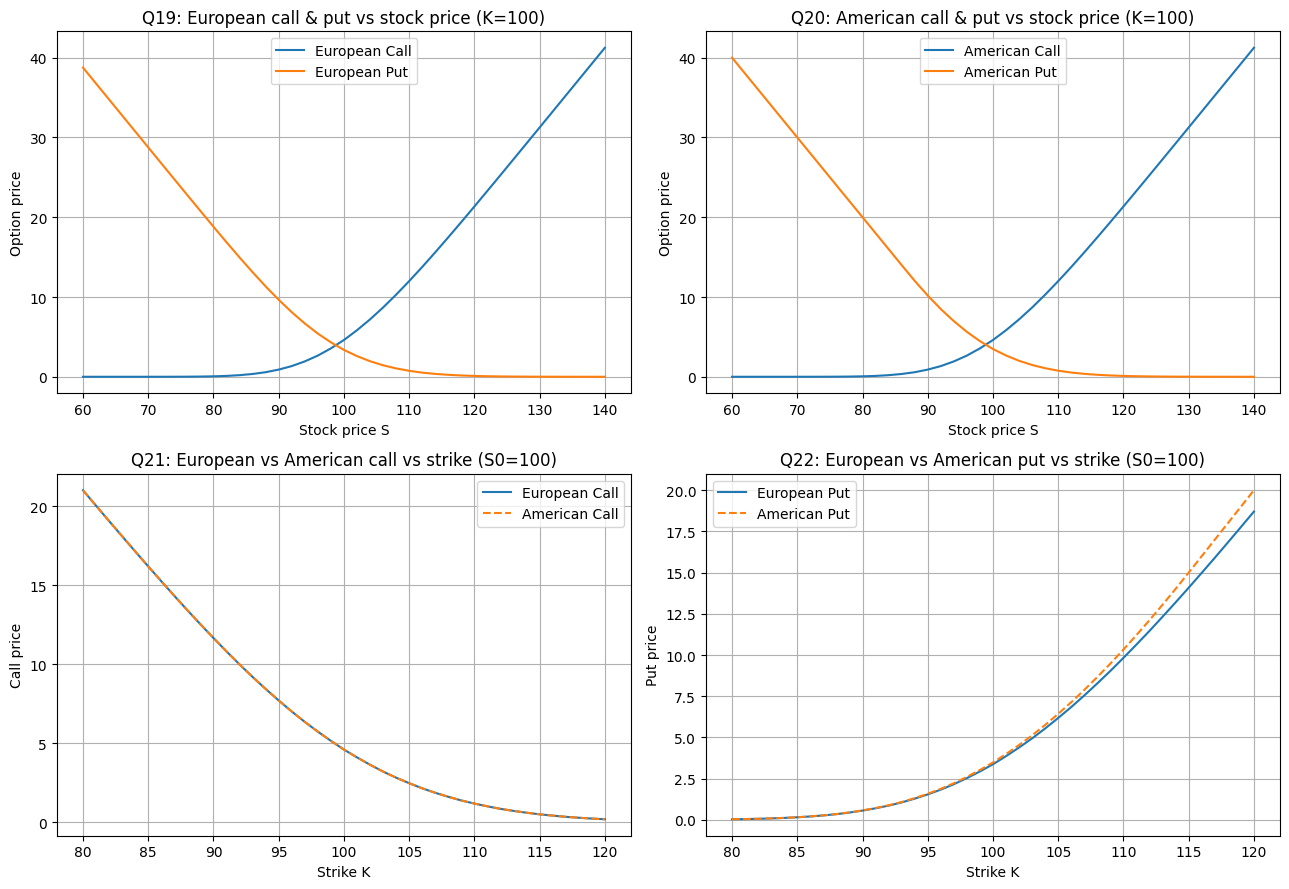

In [17]:
Ng = 200
S_grid = np.linspace(60, 140, 41)
K_grid = np.linspace(80, 120, 41)
eu_c_S = [crr_tree(S, 100, r, sigma, T, Ng, "call", False) for S in S_grid]
eu_p_S = [crr_tree(S, 100, r, sigma, T, Ng, "put", False) for S in S_grid]
am_c_S = [crr_tree(S, 100, r, sigma, T, Ng, "call", True) for S in S_grid]
am_p_S = [crr_tree(S, 100, r, sigma, T, Ng, "put", True) for S in S_grid]
eu_c_K = [crr_tree(S0, K, r, sigma, T, Ng, "call", False) for K in K_grid]
am_c_K = [crr_tree(S0, K, r, sigma, T, Ng, "call", True) for K in K_grid]
eu_p_K = [crr_tree(S0, K, r, sigma, T, Ng, "put", False) for K in K_grid]
am_p_K = [crr_tree(S0, K, r, sigma, T, Ng, "put", True) for K in K_grid]

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
ax[0, 0].plot(S_grid, eu_c_S, label="European Call")
ax[0, 0].plot(S_grid, eu_p_S, label="European Put")
ax[0, 0].set_title("Q19: European call & put vs stock price (K=100)")
ax[0, 0].set_xlabel("Stock price S")
ax[0, 0].set_ylabel("Option price")
ax[0, 0].legend()
ax[0, 0].grid(True)
ax[0, 1].plot(S_grid, am_c_S, label="American Call")
ax[0, 1].plot(S_grid, am_p_S, label="American Put")
ax[0, 1].set_title("Q20: American call & put vs stock price (K=100)")
ax[0, 1].set_xlabel("Stock price S")
ax[0, 1].set_ylabel("Option price")
ax[0, 1].legend()
ax[0, 1].grid(True)
ax[1, 0].plot(K_grid, eu_c_K, label="European Call")
ax[1, 0].plot(K_grid, am_c_K, "--", label="American Call")
ax[1, 0].set_title("Q21: European vs American call vs strike (S0=100)")
ax[1, 0].set_xlabel("Strike K")
ax[1, 0].set_ylabel("Call price")
ax[1, 0].legend()
ax[1, 0].grid(True)
ax[1, 1].plot(K_grid, eu_p_K, label="European Put")
ax[1, 1].plot(K_grid, am_p_K, "--", label="American Put")
ax[1, 1].set_title("Q22: European vs American put vs strike (S0=100)")
ax[1, 1].set_xlabel("Strike K")
ax[1, 1].set_ylabel("Put price")
ax[1, 1].legend()
ax[1, 1].grid(True)
plt.tight_layout()
plt.show()

**Q19 and Q20.** As the spot rises, call values climb and put values fall. The American and
European curves look almost the same, with the American put sitting just above the European put
because of the early-exercise premium.

**Q21.** The European and American *call* curves lie on top of each other, since a non-dividend call
is never exercised early.

**Q22.** The American *put* curve stays above the European put, and the gap widens as the strike
rises and the put moves deeper into the money.

## Q23: Put-call parity at the 5 European strikes (Q15/Q16)

In [18]:
q23 = pd.DataFrame(
    {
        "Strike K": strikes,
        "C - P": [
            trinomial_tree(S0, K, r, sigma, T, N_TRI, "call", False)
            - trinomial_tree(S0, K, r, sigma, T, N_TRI, "put", False)
            for K in strikes
        ],
        "S0 - K e^{-rT}": [S0 - K * np.exp(-r * T) for K in strikes],
    }
)
q23["difference"] = q23["C - P"] - q23["S0 - K e^{-rT}"]
q23.round(4)

,Strike K,C - P,S0 - K e^{-rT},difference
0,90.00,11.12,11.12,-0.00
1,95.00,6.18,6.18,-0.00
2,100.00,1.24,1.24,-0.00
3,105.00,-3.70,-3.70,-0.00
4,110.00,-8.63,-8.63,-0.00


Parity holds at every European strike. The difference is essentially zero across the board.
No-arbitrage pins $C-P$ to $S_0-Ke^{-rT}$ no matter how far in or out of the money the option is.

## Q24: Put-call parity at the 5 American strikes (Q17/Q18)

In [19]:
q24 = pd.DataFrame(
    {
        "Strike K": strikes,
        "C - P": [
            trinomial_tree(S0, K, r, sigma, T, N_TRI, "call", True)
            - trinomial_tree(S0, K, r, sigma, T, N_TRI, "put", True)
            for K in strikes
        ],
        "S0 - K e^{-rT}": [S0 - K * np.exp(-r * T) for K in strikes],
    }
)
q24["difference (early-ex premium)"] = q24["C - P"] - q24["S0 - K e^{-rT}"]
q24.round(4)

,Strike K,C - P,S0 - K e^{-rT},difference (early-ex premium)
0,90.00,11.11,11.12,-0.01
1,95.00,6.14,6.18,-0.04
2,100.00,1.13,1.24,-0.11
3,105.00,-3.95,-3.70,-0.25
4,110.00,-9.14,-8.63,-0.50


For American options the equality breaks down. $C-P$ falls short of $S_0-Ke^{-rT}$ by the
put's early-exercise premium, and that shortfall grows with the strike.

The values still respect the no-arbitrage band $S_0-K\le C-P\le S_0-Ke^{-rT}$. They just sit inside
it rather than on the edge.

## Step 3: Dynamic Delta Hedging
Parameters: $S_0=180$, $r=2\%$, $\sigma=25\%$, $T=0.5$ yr, $K=182$.

In [20]:
S0b, rb, sigb, Tb, Kb = 180.0, 0.02, 0.25, 0.5, 182.0

### Q25(a): European put on a 3-step binomial tree (by hand)

Step 1. Tree parameters. With $\Delta t = 0.16667$:

$$u=e^{0.25\sqrt{0.16667}}=1.1075,\quad d=1/u=0.9030,\quad p=\frac{e^{r\Delta t}-d}{u-d}=0.4908,$$

and the per-step discount factor is $e^{-r\Delta t}=0.99667$.

Step 2. The stock tree.

| | stock prices |
|---|---|
| $t_0$ | 180.00 |
| $t_1$ | 199.34 · 162.54 |
| $t_2$ | 220.76 · 180.00 · 146.77 |
| $t_3$ | 244.48 · 199.34 · 162.54 · 132.52 |

Step 3. Payoffs at maturity. Using $\max(K-S_T,0)$, the four terminal nodes pay
$0,\ 0,\ 19.46,\ 49.48$.

Step 4. Roll back. Discounting expected values one step at a time,
$V=0.99667\,(p\,V_{up}+(1-p)\,V_{down})$:

- at $t_2$: $0,\ 9.88,\ 34.63$
- at $t_1$: $5.01,\ 22.41$
- at $t_0$: $V_0=0.99667(0.4908\cdot5.01+0.5092\cdot22.41)=\boxed{13.82}$

So the European put is worth 13.82. The next cell rebuilds the tree to check this arithmetic.

In [21]:
def full_binomial(S, K, r, sigma, T, N, kind="put", american=False):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)
    Stree = [np.array([S * u ** (i - j) * d**j for j in range(i + 1)]) for i in range(N + 1)]
    Vtree = [None] * (N + 1)
    Vtree[N] = np.maximum(Stree[N] - K, 0) if kind == "call" else np.maximum(K - Stree[N], 0)
    for i in range(N - 1, -1, -1):
        cont = disc * (p * Vtree[i + 1][:-1] + (1 - p) * Vtree[i + 1][1:])
        if american:
            ex = np.maximum(Stree[i] - K, 0) if kind == "call" else np.maximum(K - Stree[i], 0)
            cont = np.maximum(cont, ex)
        Vtree[i] = cont
    Dtree = [
        (Vtree[i + 1][:-1] - Vtree[i + 1][1:]) / (Stree[i + 1][:-1] - Stree[i + 1][1:])
        for i in range(N)
    ]
    return dict(u=u, d=d, p=p, disc=disc, Stree=Stree, Vtree=Vtree, Dtree=Dtree)


tr = full_binomial(S0b, Kb, rb, sigb, Tb, 3, "put", american=False)
print(f"u={tr['u']:.4f}  d={tr['d']:.4f}  p={tr['p']:.4f}  disc={tr['disc']:.4f}")
print("Stock tree:")
[print(f" t{i}: " + "  ".join(f"{x:7.2f}" for x in a)) for i, a in enumerate(tr["Stree"])]
print("European put values:")
[print(f" t{i}: " + "  ".join(f"{x:7.4f}" for x in a)) for i, a in enumerate(tr["Vtree"])]
print(f"European put price at t0 = {tr['Vtree'][0][0]:.4f}")

u=1.1075  d=0.9030  p=0.4908  disc=0.9967
Stock tree:
 t0:  180.00
 t1:  199.34   162.54
 t2:  220.76   180.00   146.77
 t3:  244.48   199.34   162.54   132.52
European put values:
 t0: 13.8224
 t1:  5.0127  22.4056
 t2:  0.0000   9.8778  34.6293
 t3:  0.0000   0.0000  19.4648  49.4751
European put price at t0 = 13.8224


### Q25(b): Delta hedging the put as the *seller*, path up→down→down

We follow one path through the tree: up, then down, then down. The deltas at the nodes along it are
$\Delta_0=-0.4726$, $\Delta_1^{(up)}=-0.2423$ and $\Delta_2^{(down)}=-0.5288$.

As the seller we are short the put, so we hold the portfolio that replicates a *long* put: $\Delta_t$
shares (negative, meaning a short stock position) plus a cash/bond account. At each step we rebalance
the shares to the new delta, and the cash account earns interest at $e^{r\Delta t}$ between steps.

| $t$ | move | $S_t$ | $\Delta_t$ | shares traded | cash from trade | cash/bond | stock value | total |
|---|---|---|---|---|---|---|---|---|
| 0 | start | 180.00 | $-0.4726$ | short 0.4726 | $+85.06$ | 98.88 | $-85.06$ | 13.82 |
| 1 | up | 199.34 | $-0.2423$ | buy 0.2303 | $-45.91$ | 53.32 | $-48.31$ | 5.01 |
| 2 | down | 180.00 | $-0.5288$ | short 0.2865 | $+51.57$ | 105.07 | $-95.19$ | 9.88 |
| 3 | down | 162.54 | exercise | buy 0.5288 | $-85.96$ | **19.46** | 0.00 | **19.46** |

The portfolio matches the put value at every node, and the final cash of 19.46 exactly meets the
payoff, so the hedge is self-financing and replicates the put perfectly. The next cell verifies the
table.

In [22]:
def hedge_path(tr, r, T, N, path):
    dt = T / N
    grow = np.exp(r * dt)
    rows = []
    node = 0
    S_t = tr["Stree"][0][0]
    D_t = tr["Dtree"][0][0]
    V_t = tr["Vtree"][0][0]
    cash = V_t - D_t * S_t
    shares = D_t
    rows.append([0, S_t, V_t, D_t, shares, D_t * S_t, cash])
    for step, mv in enumerate(path, start=1):
        node += 0 if mv == 0 else 1
        S_t = tr["Stree"][step][node]
        cash *= grow
        D_new = tr["Dtree"][step][node] if step < N else 0.0
        V_t = tr["Vtree"][step][node]
        cash -= (D_new - shares) * S_t
        shares = D_new
        rows.append([step, S_t, V_t, D_new, shares, shares * S_t, cash])
    df = pd.DataFrame(
        rows,
        columns=["step", "S_t", "Put value", "Delta", "Shares held", "Stock value", "Cash/bond"],
    )
    df["Portfolio"] = df["Stock value"] + df["Cash/bond"]
    return df


hedge = hedge_path(tr, rb, Tb, 3, path=[0, 1, 1]).round(4)
print("Path: up, down, down  |  premium received =", round(tr["Vtree"][0][0], 4))
hedge

Path: up, down, down  |  premium received = 13.8224


,step,S_t,Put value,Delta,Shares held,Stock value,Cash/bond,Portfolio
0,0,180.00,13.82,-0.47,-0.47,-85.06,98.88,13.82
1,1,199.34,5.01,-0.24,-0.24,-48.31,53.32,5.01
2,2,180.00,9.88,-0.53,-0.53,-95.19,105.07,9.88
3,3,162.54,19.46,0.00,0.00,0.00,19.46,19.46


## Q26: American put, 25-step tree, delta hedge & cash account

In [23]:
N25 = 25
am_tr = full_binomial(S0b, Kb, rb, sigb, Tb, N25, "put", american=True)
eu_tr = full_binomial(S0b, Kb, rb, sigb, Tb, N25, "put", american=False)
print(f"American put (N=25) = {am_tr['Vtree'][0][0]:.4f}")
print(f"European put (N=25) = {eu_tr['Vtree'][0][0]:.4f}")
print(f"Early-exercise premium = {am_tr['Vtree'][0][0]-eu_tr['Vtree'][0][0]:.4f}")
path25 = [0 if i % 2 == 0 else 1 for i in range(N25)]
am_hedge = hedge_path(am_tr, rb, Tb, N25, path25).round(4)
am_hedge.head(8)

American put (N=25) = 13.0357
European put (N=25) = 12.8802
Early-exercise premium = 0.1555


,step,S_t,Put value,Delta,Shares held,Stock value,Cash/bond,Portfolio
0,0,180.00,13.04,-0.48,-0.48,-85.60,98.64,13.04
1,1,186.48,9.99,-0.40,-0.40,-73.68,83.67,9.99
2,2,180.00,12.59,-0.48,-0.48,-86.15,98.74,12.59
3,3,186.48,9.53,-0.39,-0.39,-73.61,83.14,9.53
4,4,180.00,12.12,-0.48,-0.48,-86.75,98.87,12.12
5,5,186.48,9.03,-0.39,-0.39,-73.50,82.53,9.03
6,6,180.00,11.62,-0.49,-0.49,-87.40,99.02,11.62
7,7,186.48,8.52,-0.39,-0.39,-73.33,81.85,8.52


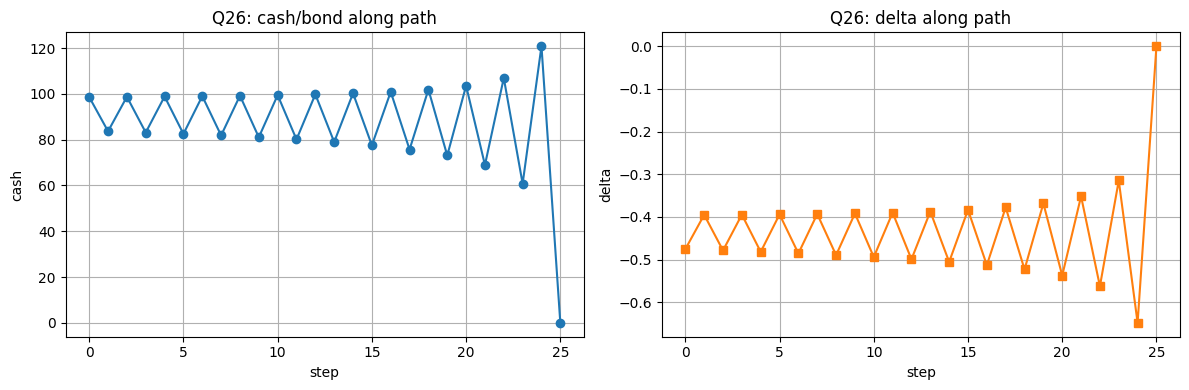

Final portfolio: 0.0  payoff: 0


In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(am_hedge["step"], am_hedge["Cash/bond"], marker="o")
ax[0].set_title("Q26: cash/bond along path")
ax[0].set_xlabel("step")
ax[0].set_ylabel("cash")
ax[0].grid(True)
ax[1].plot(am_hedge["step"], am_hedge["Delta"], marker="s", color="C1")
ax[1].set_title("Q26: delta along path")
ax[1].set_xlabel("step")
ax[1].set_ylabel("delta")
ax[1].grid(True)
plt.tight_layout()
plt.show()
print(
    "Final portfolio:",
    round(am_hedge["Portfolio"].iloc[-1], 4),
    " payoff:",
    round(max(Kb - am_hedge["S_t"].iloc[-1], 0), 4),
)

Compared with the European put, the American position has to be re-hedged more actively. Its
delta moves more sharply and heads toward −1 wherever early exercise becomes optimal, which forces
the hedger into a larger short stock position.

The cash account, plotted above, grows to fund that larger early liability. It carries the extra
value of the early-exercise right.

## Q27: Asian ATM put: price & delta hedge (Monte-Carlo)
The Asian payoff depends on the path average, so a recombining tree cannot price it directly. We
use Monte-Carlo, and hedge by nested MC (revalue + finite-difference delta at each step with
common random numbers).

In [25]:
def asian_value(S_t, partial_sum, k, N, K, r, sigma, T, normals):
    dt = T / N
    t = k * dt
    rem = N - k
    if rem == 0:
        return max(K - partial_sum / N, 0.0)
    drift = (r - 0.5 * sigma**2) * dt
    vol = sigma * np.sqrt(dt)
    Sfut = np.exp(np.log(S_t) + np.cumsum(drift + vol * normals[:, :rem], axis=1))
    return float(
        np.exp(-r * (T - t)) * np.maximum(K - (partial_sum + Sfut.sum(axis=1)) / N, 0).mean()
    )


def asian_delta(S_t, partial_sum, k, N, K, r, sigma, T, normals, h=0.01):
    Vp = asian_value(S_t * (1 + h), partial_sum + S_t * h, k, N, K, r, sigma, T, normals)
    Vm = asian_value(S_t * (1 - h), partial_sum - S_t * h, k, N, K, r, sigma, T, normals)
    return (Vp - Vm) / (2 * h * S_t)


K_asian = S0b
rng = np.random.default_rng(2024)
dt = Tb / N25
CRN = rng.standard_normal((60000, N25))
S_path = np.exp(
    np.log(S0b)
    + np.cumsum((rb - 0.5 * sigb**2) * dt + sigb * np.sqrt(dt) * rng.standard_normal(N25))
)
V0 = asian_value(S0b, 0.0, 0, N25, K_asian, rb, sigb, Tb, CRN)
grow = np.exp(rb * dt)
shares = asian_delta(S0b, 0.0, 0, N25, K_asian, rb, sigb, Tb, CRN)
cash = V0 - shares * S0b
partial = 0.0
rows = [[0, S0b, V0, shares, shares, shares * S0b, cash, shares * S0b + cash]]
for k in range(1, N25 + 1):
    S_t = S_path[k - 1]
    partial += S_t
    cash *= grow
    if k < N25:
        D_new = asian_delta(S_t, partial, k, N25, K_asian, rb, sigb, Tb, CRN)
        V_t = asian_value(S_t, partial, k, N25, K_asian, rb, sigb, Tb, CRN)
    else:
        D_new = 0.0
        V_t = max(K_asian - partial / N25, 0)
    cash -= (D_new - shares) * S_t
    shares = D_new
    rows.append([k, S_t, V_t, D_new, shares, shares * S_t, cash, shares * S_t + cash])
asian_hedge = pd.DataFrame(
    rows,
    columns=[
        "step",
        "S_t",
        "Asian put value",
        "Delta",
        "Shares held",
        "Stock value",
        "Cash account",
        "Portfolio",
    ],
).round(4)
payoff = max(K_asian - partial / N25, 0)
print(f"Asian put t0 value = {V0:.4f}")
print(f"Realised average = {partial/N25:.4f}   terminal payoff = {payoff:.4f}")
print(
    f"Final cash = {asian_hedge['Cash account'].iloc[-1]:.4f}   hedging residual = {asian_hedge['Cash account'].iloc[-1]-payoff:.4f}"
)
asian_hedge.head(8)

Asian put t0 value = 7.0244
Realised average = 172.4238   terminal payoff = 7.5762
Final cash = 7.4353   hedging residual = -0.1409


,step,S_t,Asian put value,Delta,Shares held,Stock value,Cash account,Portfolio
0,0,180.00,7.02,-0.48,-0.48,-86.42,93.44,7.02
1,1,172.48,10.73,-0.63,-0.63,-108.65,119.32,10.67
2,2,164.46,15.97,-0.77,-0.77,-126.10,141.87,15.77
3,3,163.86,16.22,-0.76,-0.76,-124.24,140.52,16.29
4,4,164.40,15.66,-0.73,-0.73,-120.54,136.48,15.94
5,5,157.86,20.41,-0.78,-0.78,-123.12,143.90,20.79
6,6,166.43,14.19,-0.68,-0.68,-112.54,126.69,14.16
7,7,173.64,9.63,-0.56,-0.56,-97.21,106.54,9.33


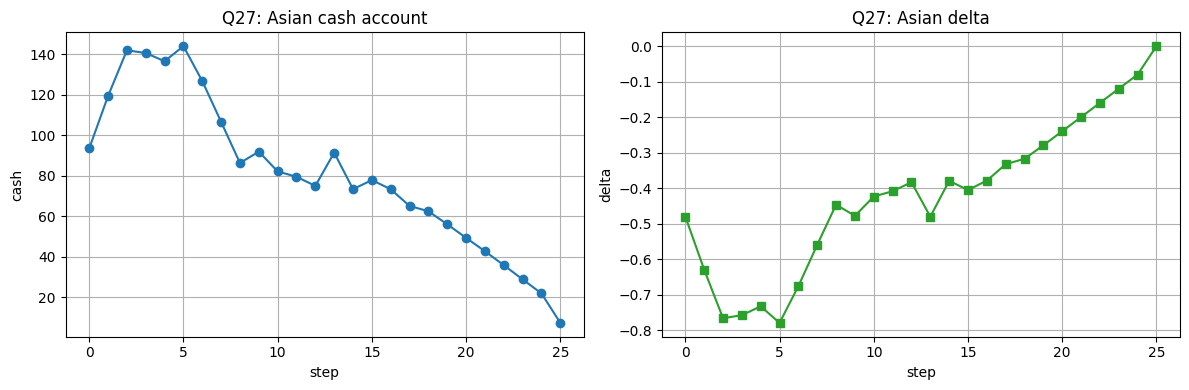

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(asian_hedge["step"], asian_hedge["Cash account"], marker="o")
ax[0].set_title("Q27: Asian cash account")
ax[0].set_xlabel("step")
ax[0].set_ylabel("cash")
ax[0].grid(True)
ax[1].plot(asian_hedge["step"], asian_hedge["Delta"], marker="s", color="C2")
ax[1].set_title("Q27: Asian delta")
ax[1].set_xlabel("step")
ax[1].set_ylabel("delta")
ax[1].grid(True)
plt.tight_layout()
plt.show()

The Asian put is worth about 7.02, far less than the American put at 13.04. Averaging
the price over the path smooths out the swings, so the payoff varies much less and the option is
cheaper.

Two things stand out in the hedge. First, the delta is smoother and shrinks as expiry nears, because
more of the average is already locked in. The seller rebalances gently rather than in jumps.

Second, the hedge leaves a small residual instead of reconciling to the cent. That gap is the
discretisation and path-dependence error. We hedge at only 25 dates and estimate delta by
simulation. It is the honest, expected outcome, and it shows why path-dependent options are harder to
hedge than plain vanilla ones.

## Summary of computed prices

| Q | Result | Q | Result |
|---|---|---|---|
| Q5 Eu call/put | 4.61 / 3.37 | Q15/16 trinomial Eu | see tables |
| Q6 Eu delta | +0.57 / −0.43 | Q17/18 trinomial Am | Am call = Eu; Am put > Eu |
| Q7 Eu vega | +0.99 / +0.98 | Q19–22 graphs | plotted |
| Q8 Am call/put | 4.61 / 3.48 | Q23 Eu parity | holds |
| Q9 Am delta | +0.57 / −0.45 | Q24 Am parity | band only |
| Q10 Am vega | +0.99 / +0.98 | Q25 Eu put 3-step | 13.82 |
| Q11 Eu parity | holds | Q26 Am put 25-step | 13.04 |
| Q12 Am parity | band only | Q27 Asian put | 7.02 |
| Q13/14 Eu≤Am | call =, put +0.11 | | |